# Heart Disease Classification Pipeline
This notebook provides a pipeline for binary classification of heart disease prediction.

## Steps Covered:
- Data loading
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training using a pipeline
- Hyperparameter tuning
- Model evaluation

## Import the modules needed for the project

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import seaborn as sns

The dataset used in this project was sourced from Kaggle. It is the "Heart Failure Prediction Dataset" created and shared by the user Fedesoriano.
This dataset contains clinical records of heart failure patients sourced from https://archive.ics.uci.edu/ml/datasets/Heart+Disease.

> ### Description
>
> - Context: Heart disease is the leading cause of death around the world. According to the World Health Organization, heart disease accounted for 13% of global deaths in 2021. The number of heart disease deaths has been rising, increasing from 2.1 million to 9.1 million in 2021. Work needs to be done to manage heart disease deaths better. 
>
> - Content: This project aims to predict which patients are most likely to develop heart disease based on the available features.



In [4]:
# Load heart disease dataset
data = pd.read_csv("heart_disease_original.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Exploratory Data Analytics

In [5]:
# Print a quick summary of the data and statistical information
data.info()
print()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Observations

1. There seems to be potential outliers in the dataset, specifically in blood pressure and cholesterol measurements.

2. The minimum values of 0.0 for resting blood pressure and cholesterol likely represent missing data rather than actual measurements.

3. The maximum values, 200.0 for resting blood pressure and 603.0 for cholesterol, are extremely high and potentially concerning from a medical perspective.

4. The maximum heart rate interquartile range measurements suggest that these were taken during exercise testing rather than at rest.


In [6]:
print(data.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


The dataset does not contain any missing values.

### Target Variable Distribution Count

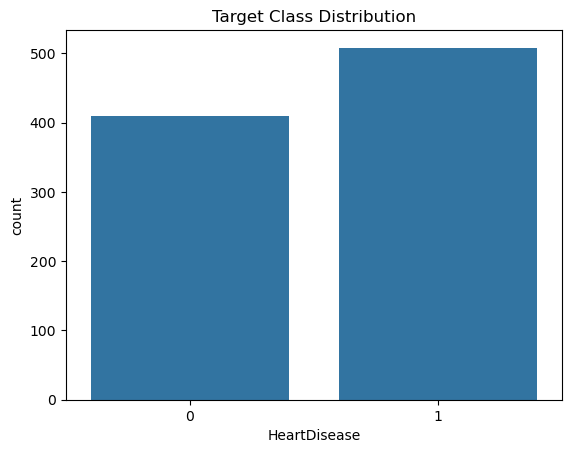

In [7]:
sns.countplot(x='HeartDisease', data=data)
plt.title('Target Class Distribution')
plt.show()

## Data Preprocessing

Ensure proper handling of different data types before model training.

1. First, separate features (`X`) from the target variable (`y`):

2. Identify different feature types:
   - `numeric_features` captures all numerical columns
   - `categorical_features` captures all object/string columns

3. Create specialized preprocessing pipelines:
   - For numeric features: applies the mean for missing values, then standardizes the data
   - For categorical features: fills missing values with the most frequent value, then applies one-hot encoding

4. Finally, combine these pipelines into a single `ColumnTransformer` that will:
   - Apply the numeric pipeline to all numeric columns
   - Apply the categorical pipeline to all categorical columns
   - Process both types of features appropriately in parallel

In [8]:
# Define features and target
X = data.drop('HeartDisease', axis=1) 
y = data['HeartDisease']

# Identify feature types
numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Split the data into 80% training and 20% testing sets.
Fit the pipeline with the training data.

In [9]:
# Define the model pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit the model
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=1))])

Here we are using the classifier to make predictions on the testing dataset.

We also want to print a report on how well the model did.

In [10]:
# Predictions and evaluation
y_pred = clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        74
           1       0.91      0.93      0.92       110

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184

Accuracy Score: 0.90


### Observations
 - The model did relatively well with 90% correct predictions.
 - The F1-scores for both classes are close, indicating that the model is well-balanced and does not overly favor one class.
 - Class 1 slightly outperforms Class 0 in all metrics, suggesting the model is more effective at correctly identifying instances of Class 1.

## Hyperparameter Tuning

In [11]:
# Create a 5-fold cross-validator
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [12]:
# Grid search for hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(clf, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.2f}")

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best Cross-validation Accuracy: 0.86


### Observations
The model performs its best with
- Max Depth: 10
- Min Samples Split: 5
- Num Estimators: 100

### Confusion Matrix

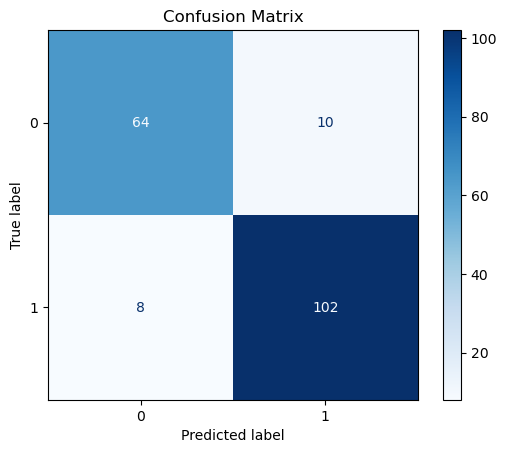

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

The model obtained a true positive rate of 102/112 or 91% rate.

The model classified 8 positive heart disease cases as class 0.

## Feature Engineering

In [14]:
feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

In [15]:
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

cat_pipeline = grid_search.best_estimator_['preprocessor'].named_transformers_['cat']
onehot_encoder = cat_pipeline.named_steps['onehot']

cat_feature_names = list(onehot_encoder.get_feature_names_out(categorical_features))
print("Number of one-hot encoded categorical features:", len(cat_feature_names))

feature_names = list(numeric_features) + cat_feature_names
print("Total feature names count:", len(feature_names))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_
print("Feature importances count:", len(feature_importances))

Number of numeric features: 6
Number of categorical features: 5
Number of one-hot encoded categorical features: 14
Total feature names count: 20
Feature importances count: 20


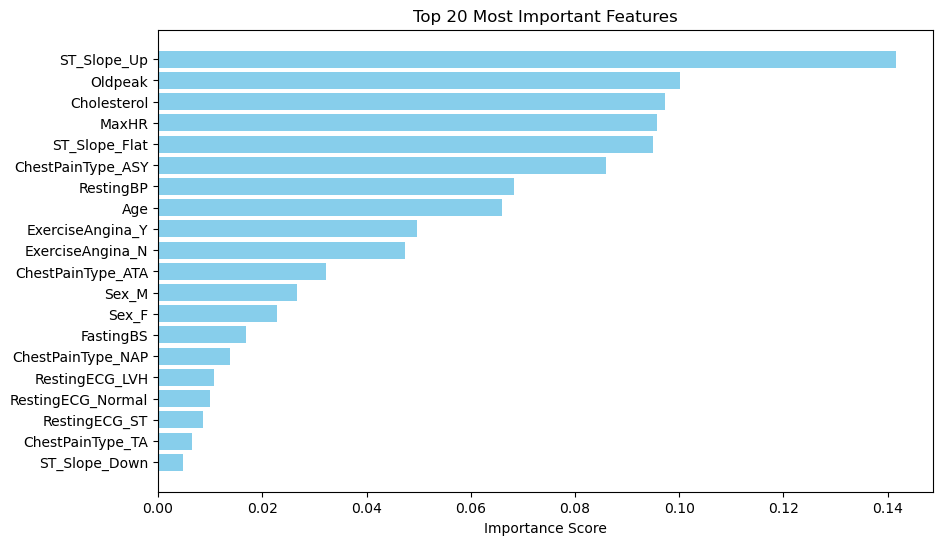

In [16]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

N = 20  # Number of top features to plot
top_features = importance_df.head(N)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Most important on top
plt.title(f'Top {N} Most Important Features')
plt.xlabel('Importance Score')
plt.show()

### Observations
- ST_Slope, Oldpeak, MaxHR, cholestoral, and ChestPainType_ASY have high importance in determining heart disease.
- RestingBP, Age, and ExerciseAngina_Y have moderate importance in determing heart disease.
- All features falling below a score 0.05 have low importance in determinig heart disease.

### Author
Kris Treska